In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from src.config import database_url

In [7]:
engine = create_engine(database_url)

# Biểu đồ phân bổ mức lương theo vị trí

In [26]:
query_salary = """
SELECT
    normalized_job_title,
    salary_unit,
    COALESCE(
        (min_salary + max_salary) / 2.0,
        min_salary,
        max_salary
    ) AS salary_value
FROM cleaned_jobs
WHERE salary_unit IN ('VND', 'USD')
  AND (min_salary IS NOT NULL OR max_salary IS NOT NULL)
  AND normalized_job_title NOT IN ('Other');
"""

df_salary = pd.read_sql(query_salary, con=engine)

df_vnd = df_salary[df_salary["salary_unit"] == "VND"].copy()

df_usd = df_salary[df_salary["salary_unit"] == "USD"].copy()

df_vnd["salary_million"] = (df_vnd["salary_value"] / 1_000_000)

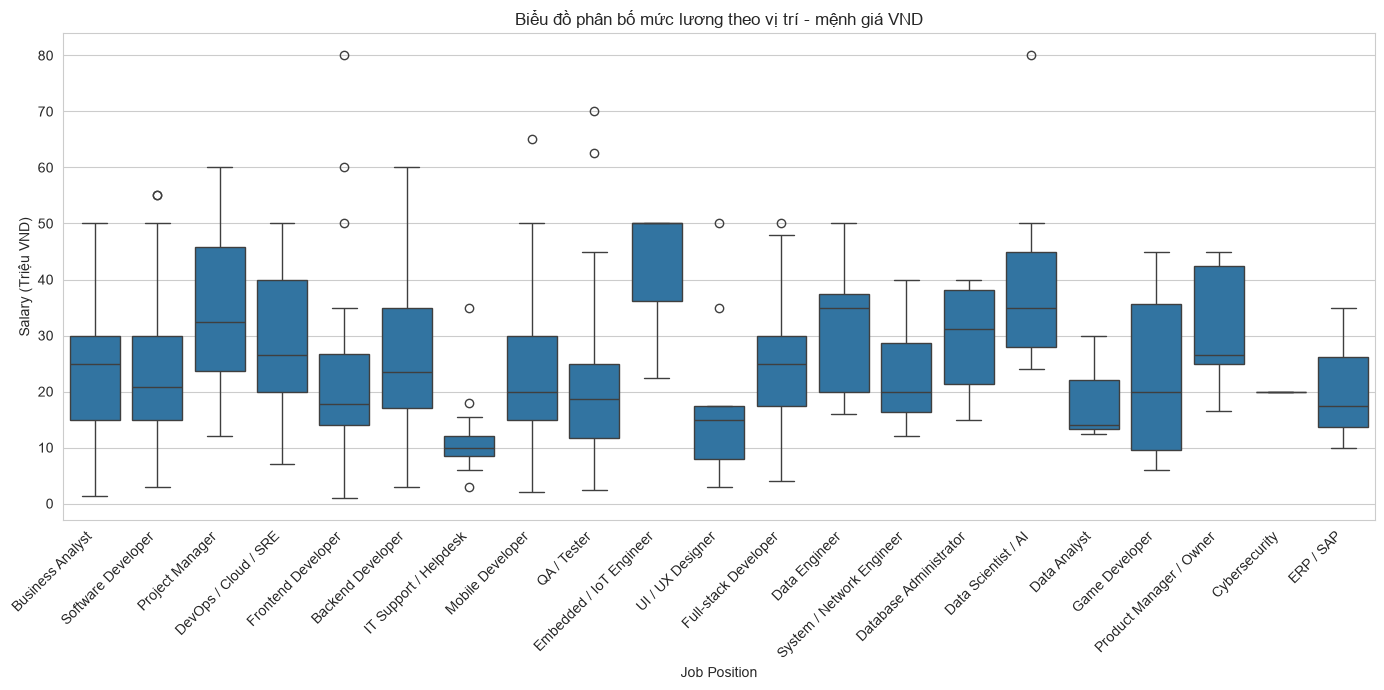

In [27]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=df_vnd, x="normalized_job_title", y="salary_million")

plt.xlabel("Job Position")
plt.ylabel("Salary (Triệu VND)")
plt.title("Biểu đồ phân bố mức lương theo vị trí - mệnh giá VND")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

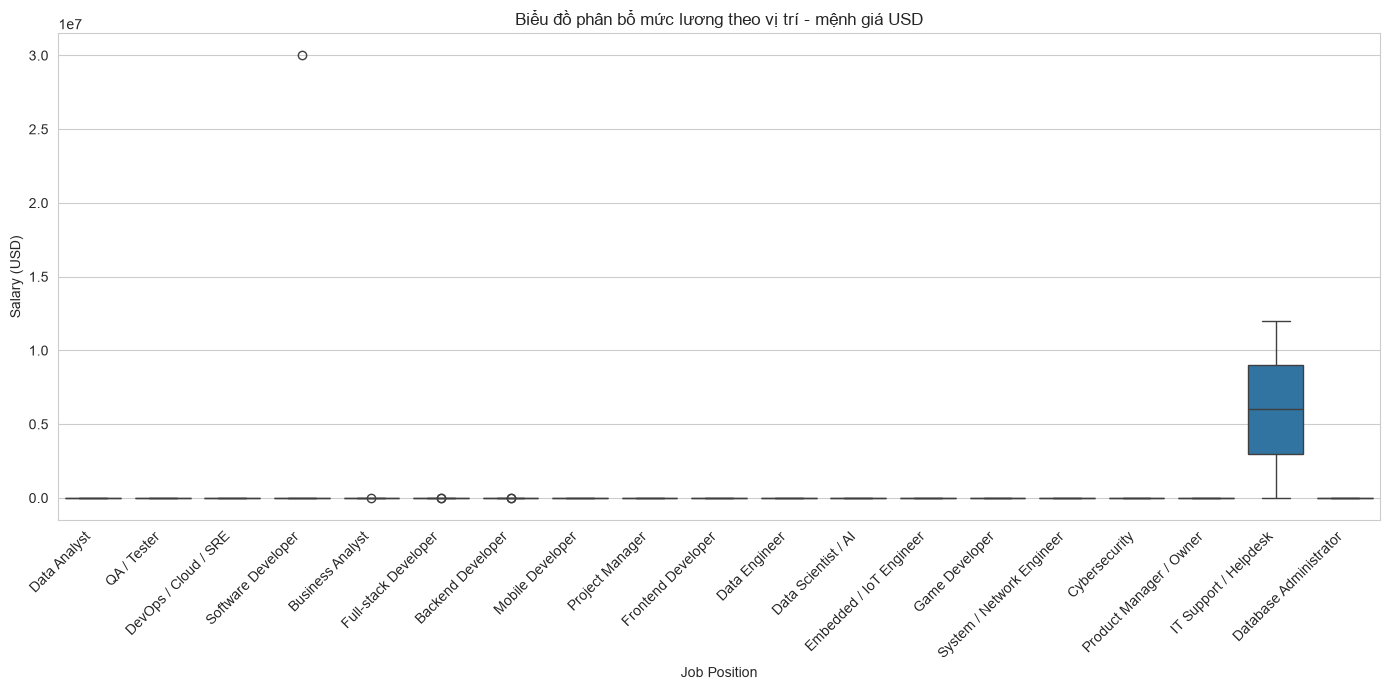

In [28]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=df_usd, x="normalized_job_title", y="salary_value")

plt.xlabel("Job Position")
plt.ylabel("Salary (USD)")
plt.title("Biểu đồ phân bổ mức lương theo vị trí - mệnh giá USD")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [23]:
df_usd.sort_values("salary_value", ascending=False).head(10)

,normalized_job_title,salary_unit,salary_value
466,Software Developer,USD,30000000.0
488,IT Support / Helpdesk,USD,12000000.0
101,Business Analyst,USD,3000.0
100,Project Manager,USD,3000.0
236,Full-stack Developer,USD,3000.0
157,Full-stack Developer,USD,3000.0
301,Mobile Developer,USD,3000.0
209,Mobile Developer,USD,3000.0
159,Full-stack Developer,USD,3000.0
582,Software Developer,USD,3000.0


# Heatmap phân bố việc làm theo khu vực

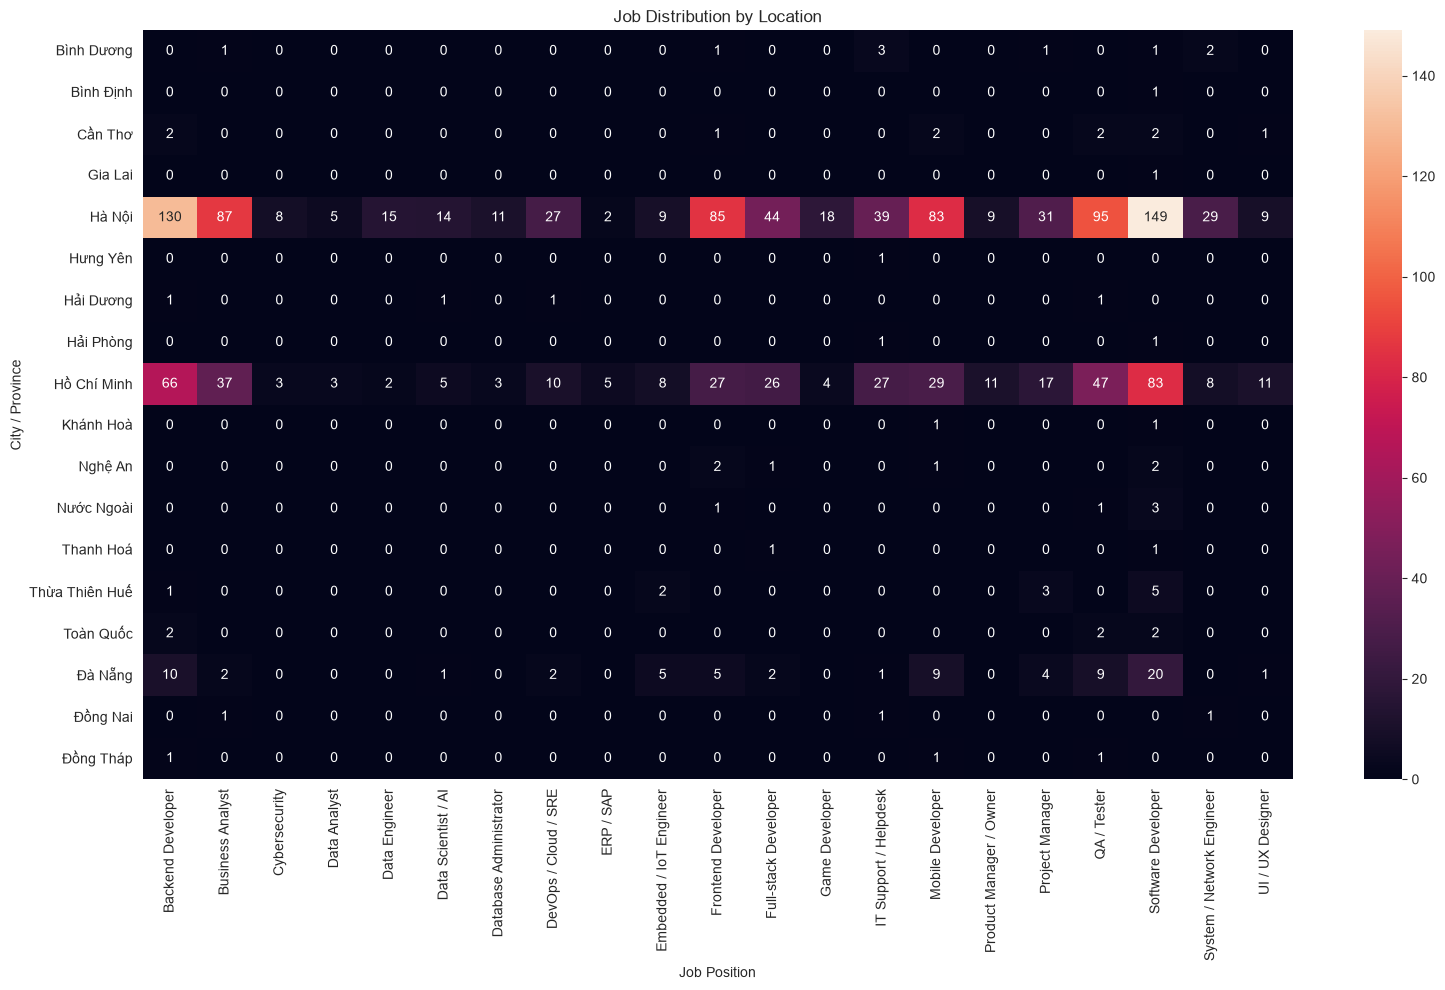

In [29]:
query_location = """
WITH expanded_locations AS (
    SELECT
        normalized_job_title,
        TRIM(location) AS location
    FROM cleaned_jobs
    CROSS JOIN LATERAL unnest(
        string_to_array(clean_address, ';')
    ) AS location
    WHERE clean_address IS NOT NULL
      AND clean_address <> ''
),
city_extracted AS (
    SELECT
        normalized_job_title,
        TRIM(
            split_part(location, ' - ', 1)
        ) AS city
    FROM expanded_locations
)
SELECT
    city,
    normalized_job_title,
    COUNT(*) AS job_count
FROM city_extracted
WHERE normalized_job_title NOT IN ('Other')
GROUP BY
    city,
    normalized_job_title
ORDER BY
    city,
    job_count DESC;
"""

df_location = pd.read_sql(query_location, con=engine)

heatmap_data = df_location.pivot(index="city", columns="normalized_job_title", values="job_count").fillna(0)

plt.figure(figsize=(16, 10))

sns.heatmap(heatmap_data, annot=True, fmt=".0f")

plt.title("Job Distribution by Location")
plt.xlabel("Job Position")
plt.ylabel("City / Province")

plt.tight_layout()
plt.show()

# Biểu đồ xu hướng công nghệ hot

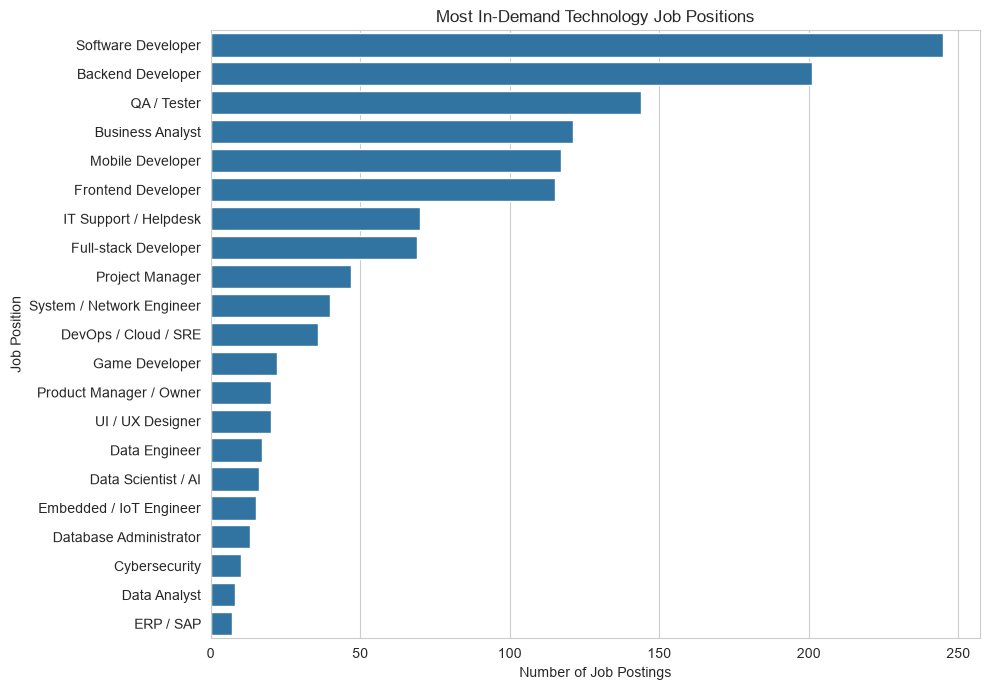

In [30]:
query_job_trend = """
SELECT
    normalized_job_title,
    COUNT(*) AS job_count
FROM cleaned_jobs
WHERE normalized_job_title NOT IN ('Other')
GROUP BY normalized_job_title
ORDER BY job_count DESC;
"""

df_job_trend = pd.read_sql(query_job_trend, con=engine)

plt.figure(figsize=(10, 7))

sns.barplot(data=df_job_trend, x="job_count", y="normalized_job_title")

plt.xlabel("Number of Job Postings")
plt.ylabel("Job Position")
plt.title("Most In-Demand Technology Job Positions")

plt.tight_layout()
plt.show()